# 06 · Sesión · Regresión y primera clasificación


## ¿Qué vas a entender al terminar?

1. Qué es un **modelo supervisado** y para qué sirve.
2. La diferencia entre **regresión** (predecir un número) y **clasificación** (predecir una categoría).
3. Por qué partimos los datos en **train / test**.
4. Cómo se leen las **métricas** básicas (MAE, MSE, R², accuracy, matriz de confusión).
5. Cómo interpretar un **gráfico real vs predicho** y un **gráfico de clases**.

> No vamos a ver todos los algoritmos ni todas las herramientas. Vamos a lo esencial para que después sepas qué preguntar y qué buscar.

---

## 0 · Antes de empezar

Este recordatorio rápido te ayudará.

- `df.head()` — enseña las 5 primeras filas de un dataframe.
- `df.describe()` — estadísticas de las columnas numéricas.
- `df.info()` — tipos de dato y si faltan valores.
- `df['columna']` — selecciona una columna.
- `df.drop(columns='x')` — quita la columna `x`.
- `plt.scatter(x, y)` — dibuja puntos.
- `print(...)` — enseña texto por pantalla.

---

## Parte A · Regresión: predecir un número

**Idea central:** tenemos datos con una variable que queremos predecir (`y`, *target*) y otras que usamos para predecirla (`X`, *features*). El modelo aprende una relación entre ellas a partir de los datos.

### A.1 · ¿Qué es un modelo supervisado?

Le damos al modelo **datos con la respuesta correcta** y él aprende la relación.

- **Regresión** → la respuesta es un número (precio, temperatura, ventas).
- **Clasificación** → la respuesta es una categoría (spam/no spam, especie de flor).

En ambos casos el flujo es el mismo:

```
datos con respuesta → entrenar el modelo → predecir sobre datos nuevos
```

### A.2 · Imports y dataset

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [41]:
data = load_diabetes(as_frame=True)
df = data.frame.copy()
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


### A.3 · Exploración

In [42]:
# Mira el dataframe: tamaño, columnas, rangos, tipos

### A.4 · Separar X e y
La columna `target` es lo que queremos predecir. El resto, las features.

In [44]:
X = df.drop(columns='target')
y = df['target']

print('X:', X.shape, '— features')
print('y:', y.shape, '— target')

X: (442, 10) — features
y: (442,) — target


### A.5 · Train / test split

**¿Por qué partir los datos?**

Si entrenamos y evaluamos con los **mismos** datos, el modelo "se los aprende de memoria" y parece muy bueno. Pero fallará con datos nuevos.

Por eso guardamos una parte (test, ~20%) que **no ve el modelo** durante el entrenamiento, y la usamos solo para evaluarlo al final.

In [45]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print('Train:', X_train.shape, '—', round(100 * len(X_train)/len(X)), '%')
print('Test :', X_test.shape,  '—', round(100 * len(X_test)/len(X)),  '%')

Train: (353, 10) — 80 %
Test : (89, 10) — 20 %


### A.6 · Entrenar y predecir
El modelo se ajusta con `fit` y predice con `predict`. Solo eso.

In [46]:
model = LinearRegression()
model.fit(X_train, y_train)         # aprende de los datos de train
y_pred = model.predict(X_test)      # predice sobre test (datos que no ha visto)

### A.7 · Métricas: MAE, MSE, R²
Tres formas de medir el error medio:

In [47]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2  = r2_score(y_test, y_pred)

print(f'MAE : {mae:.2f}  → error absoluto medio (en las mismas unidades que y)')
print(f'MSE : {mse:.2f}  → error cuadrático medio (penaliza más los errores grandes)')
print(f'RMSE: {rmse:.2f}  → raíz del MSE, en las mismas unidades que y')
print(f'R²  : {r2:.3f}  → % de varianza explicada (1 = perfecto, 0 = predecir la media)')

MAE : 42.79  → error absoluto medio (en las mismas unidades que y)
MSE : 2900.19  → error cuadrático medio (penaliza más los errores grandes)
RMSE: 53.85  → raíz del MSE, en las mismas unidades que y
R²  : 0.453  → % de varianza explicada (1 = perfecto, 0 = predecir la media)


### A.8 · Gráfico real vs predicho
Si el modelo fuera perfecto, todos los puntos caerían sobre la línea roja.

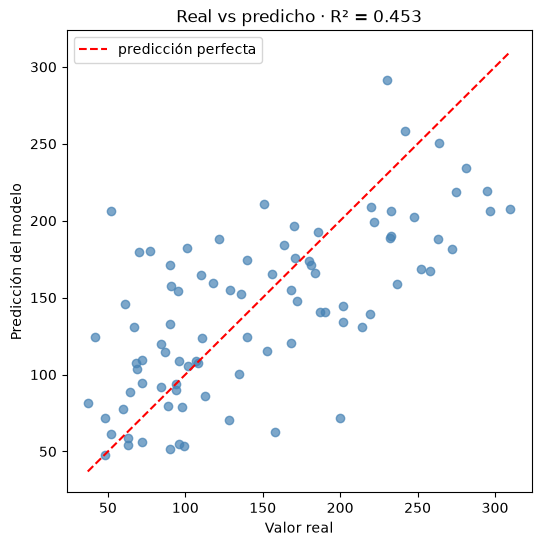

In [48]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.7, color='steelblue')
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, '--', color='red', label='predicción perfecta')
plt.xlabel('Valor real')
plt.ylabel('Predicción del modelo')
plt.title(f'Real vs predicho · R² = {r2:.3f}')
plt.legend()
plt.show()

### A.9 · ¿Y si usamos solo una variable?
Menos información → peor resultado. Esta intuición es la base del *feature engineering*.

In [49]:
print('R² con todas las variables: ', round(r2, 3))
print()
for col in X.columns:
    Xi = df[[col]]
    Xi_tr, Xi_te, yi_tr, yi_te = train_test_split(Xi, y, test_size=0.2, random_state=42)
    mi = LinearRegression().fit(Xi_tr, yi_tr)
    r2i = r2_score(yi_te, mi.predict(Xi_te))
    print(f'  {col:8s} → R² = {r2i:.3f}')

R² con todas las variables:  0.453

  age      → R² = 0.008
  sex      → R² = -0.009
  bmi      → R² = 0.233
  bp       → R² = 0.173
  s1       → R² = 0.056
  s2       → R² = 0.045
  s3       → R² = 0.185
  s4       → R² = 0.197
  s5       → R² = 0.383
  s6       → R² = 0.110


### A.10 · Mini práctica

1. Cambia el `random_state` del `train_test_split` (por ejemplo `0`, `7`, `99`). ¿Cambian las métricas? ¿Te parece estable el resultado?
2. Entrena el modelo solo con las 3 features con mayor R² individual. ¿Mejora o empeora vs usar las 10?

In [50]:
# Tu código aquí

---

## Parte B · Clasificación: predecir una categoría

**Idea central:** ahora el *target* es una clase, no un número. Cambian dos cosas:

- El modelo: usamos **LogisticRegression** (a pesar del nombre, clasifica).
- Las métricas: **accuracy** (% de aciertos) y la **matriz de confusión** (dónde falla).

### B.1 · Dataset: flores Iris
Dataset clásico: 150 flores, 4 medidas, 3 especies.

In [51]:
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [52]:
iris = load_iris(as_frame=True)
df = iris.frame.copy()
print('Shape:', df.shape)
print('Clases:', iris.target_names)
df.head()

Shape: (150, 5)
Clases: ['setosa' 'versicolor' 'virginica']


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


### B.2 · Separar X e y + split

In [53]:
X = df.drop(columns='target')
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y   # stratify mantiene la proporción de clases
)

### B.3 · Entrenar y predecir

In [54]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

### B.4 · Métricas

In [55]:
acc = accuracy_score(y_test, y_pred)
print(f'Accuracy: {acc:.3f}  → {round(acc*100)}% de aciertos')
print()
print('Matriz de confusión (filas = real, columnas = predicho):')
print(confusion_matrix(y_test, y_pred))
print()
print(classification_report(y_test, y_pred, target_names=iris.target_names))

Accuracy: 0.967  → 97% de aciertos

Matriz de confusión (filas = real, columnas = predicho):
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



### B.5 · Cómo leer la matriz
- **Diagonal** = aciertos.  
- **Fuera de la diagonal** = errores.  
  Por ejemplo, `1` en la posición (versicolor, virginica) significa: 1 flor versicolor fue clasificada como virginica.

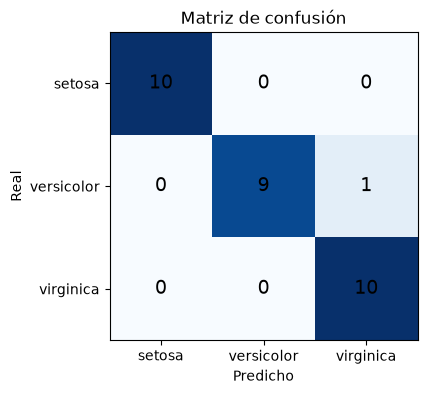

In [56]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
plt.imshow(cm, cmap='Blues')
for (i, j), v in np.ndenumerate(cm):
    plt.text(j, i, v, ha='center', va='center', fontsize=14)
plt.xticks([0, 1, 2], iris.target_names)
plt.yticks([0, 1, 2], iris.target_names)
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.title('Matriz de confusión')
plt.show()

### B.6 · Gráfico de las clases
Con 2 medidas se ve muy claro. Las clases no se mezclan mucho.

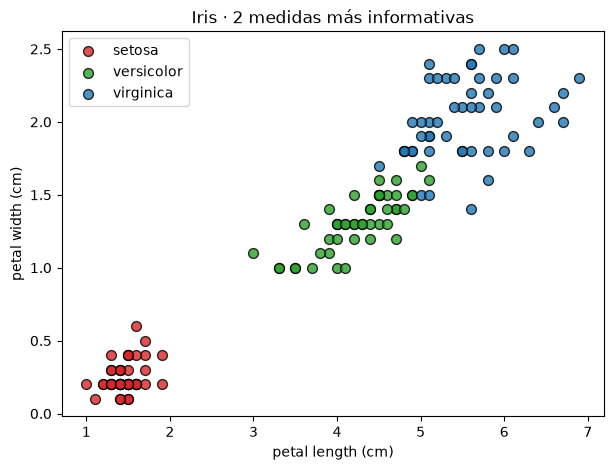

In [57]:
plt.figure(figsize=(7, 5))
colors = ['#d62728', '#2ca02c', '#1f77b4']
for clase, color in zip(iris.target_names, colors):
    sub = df[df['target'] == list(iris.target_names).index(clase)]
    plt.scatter(sub['petal length (cm)'], sub['petal width (cm)'],
                label=clase, s=50, color=color, edgecolor='k', alpha=0.8)
plt.xlabel('petal length (cm)')
plt.ylabel('petal width (cm)')
plt.title('Iris · 2 medidas más informativas')
plt.legend()
plt.show()

### B.7 · ¿Y con menos variables?

Menos features → menos información → accuracy más bajo.

In [58]:
print(f'Accuracy con las 4 features: {acc:.3f}')
print()
for col in iris.feature_names:
    Xi = df[[col]]
    Xi_tr, Xi_te, yi_tr, yi_te = train_test_split(
        Xi, y, test_size=0.2, random_state=42, stratify=y
    )
    mi = LogisticRegression(max_iter=1000).fit(Xi_tr, yi_tr)
    print(f'  {col:20s} → accuracy = {accuracy_score(yi_te, mi.predict(Xi_te)):.3f}')

Accuracy con las 4 features: 0.967

  sepal length (cm)    → accuracy = 0.567
  sepal width (cm)     → accuracy = 0.667
  petal length (cm)    → accuracy = 0.933
  petal width (cm)     → accuracy = 0.933


### B.8 · Mini práctica

1. Cambia el `random_state` del split. ¿Se mantiene el accuracy?
2. Predice a qué especie pertenece una flor con `petal length=5.1, petal width=1.8, sepal length=6.5, sepal width=2.8` (pista: `model.predict([[6.5, 2.8, 5.1, 1.8]])`).

In [59]:
# Tu código aquí

---

## Cierre

| | Regresión | Clasificación |
|---|---|---|
| Target | número | categoría |
| Modelo que hemos visto | `LinearRegression` | `LogisticRegression` |
| Métrica principal | R² + MAE/RMSE | accuracy + matriz de confusión |
| Gráfico útil | real vs predicho | scatter coloreado por clase |

**Para qué se usa esto en la realidad:**

- Regresión → predecir ventas, precios, demanda, temperatura, riesgo numérico.
- Clasificación → detectar spam, diagnosticar (sí/no), recomendar (¿le gustará?), clasificar imágenes.

**Lo que NO hemos visto y queda para más adelante:** validar con cross-validation, limpiar outliers, regularización, árboles, ensembles, deep learning. Lo vemos en la sesión 2 (los dos primeros) y en sesiones futuras el resto.